In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

from src.model import run_all, results_table, CORE_FEATURES

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

# Train all models (no MLflow for notebook)
results = run_all(log_to_mlflow=False)
baseline, lr, xgb = results

## 1. Model Comparison

                             Model Accuracy Log Loss Brier Score ROC AUC
              Baseline (Seed Only)   0.6994   0.6101      0.2019  0.7106
Logistic Regression (All Features)   0.7731   0.4815      0.1569  0.8036
                           XGBoost   0.7848   0.4634      0.1498  0.8183


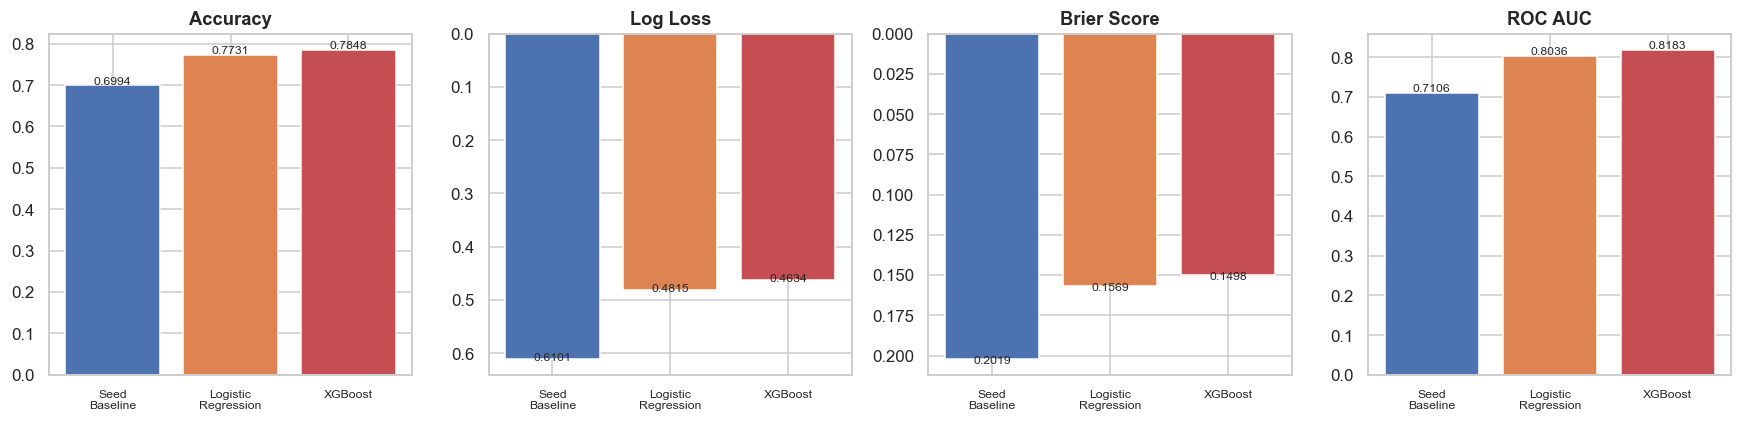

In [2]:
# Results comparison table
table = results_table(results)
print(table.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ["Accuracy", "Log Loss", "Brier Score", "ROC AUC"]
colors = ["#4c72b0", "#dd8452", "#c44e52"]

for ax, metric in zip(axes, metrics):
    vals = [float(table.loc[i, metric]) for i in range(3)]
    bars = ax.bar(range(3), vals, color=colors)
    ax.set_title(metric, fontweight="bold")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["Seed\nBaseline", "Logistic\nRegression", "XGBoost"], fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", fontsize=8)
    # Lower is better for log loss and brier
    if metric in ["Log Loss", "Brier Score"]:
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 2. Calibration Plots\nA well-calibrated model means: when it says "70% chance player 1 wins", player 1 should actually win ~70% of the time. This matters more than raw accuracy for useful predictions.

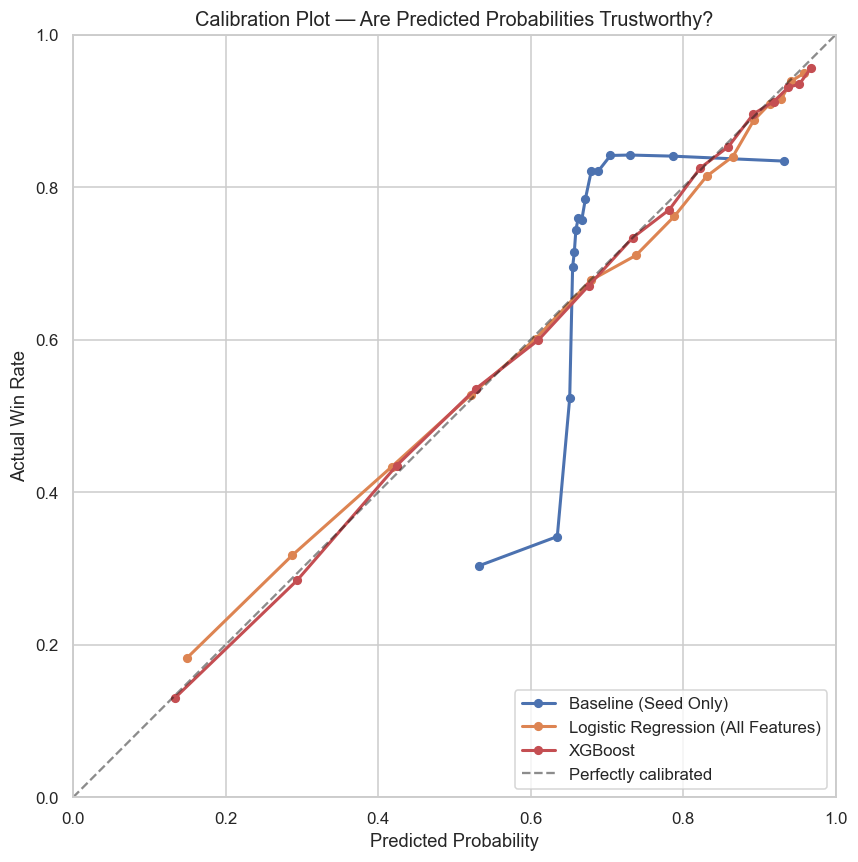

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))

for r, color in zip(results, ["#4c72b0", "#dd8452", "#c44e52"]):
    prob_true, prob_pred = calibration_curve(r.y_true, r.y_prob, n_bins=15, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=r.name, color=color, lw=2, markersize=5)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfectly calibrated")
ax.set_xlabel("Predicted Probability", fontsize=12)
ax.set_ylabel("Actual Win Rate", fontsize=12)
ax.set_title("Calibration Plot — Are Predicted Probabilities Trustworthy?", fontsize=13)
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 3. XGBoost Feature Importance\nWhich features matter most for predicting set outcomes?

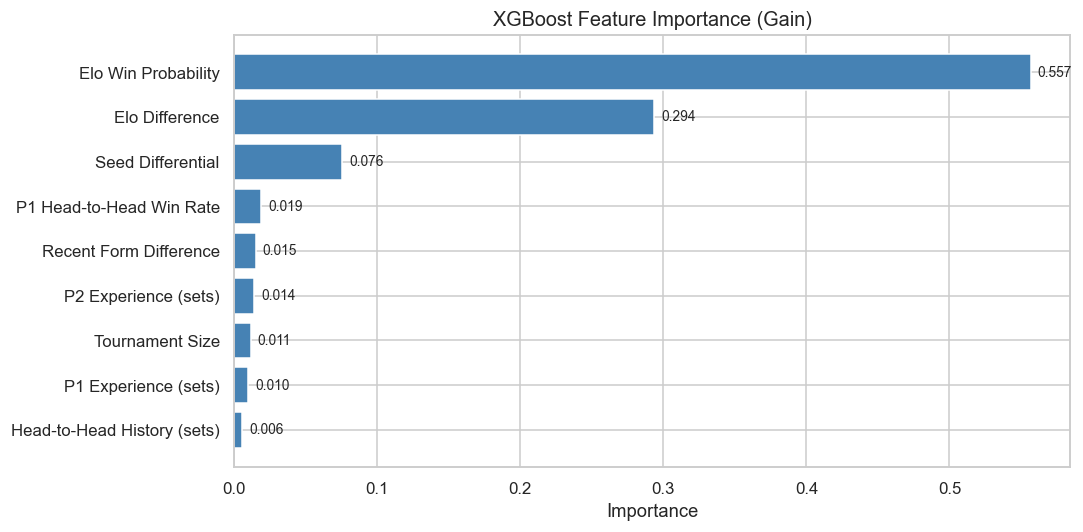

In [4]:
# Feature importance from XGBoost
feat_imp = pd.Series(xgb.feature_importances, index=xgb.feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

# Readable names
name_map = {
    "elo_diff": "Elo Difference",
    "p1_expected": "Elo Win Probability",
    "p1_sets_played": "P1 Experience (sets)",
    "p2_sets_played": "P2 Experience (sets)",
    "recent_wr_diff": "Recent Form Difference",
    "p1_h2h_wr": "P1 Head-to-Head Win Rate",
    "h2h_total": "Head-to-Head History (sets)",
    "seed_diff": "Seed Differential",
    "num_attendees": "Tournament Size",
}
labels = [name_map.get(f, f) for f in feat_imp.index]

bars = ax.barh(labels, feat_imp.values, color="steelblue", edgecolor="white")
ax.set_title("XGBoost Feature Importance (Gain)", fontsize=13)
ax.set_xlabel("Importance")

for bar, v in zip(bars, feat_imp.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Prediction Confidence vs Accuracy\nHow does the model perform when it's confident vs uncertain?

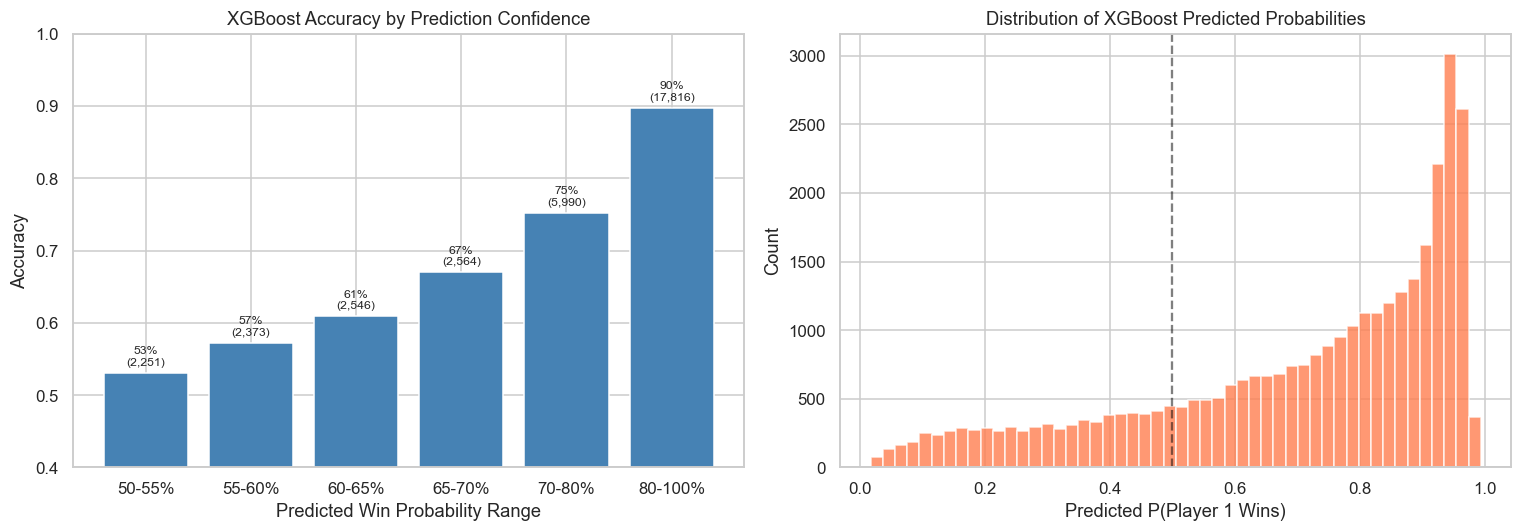

In [5]:
# Analyze XGBoost predictions by confidence bucket
y_true = xgb.y_true
y_prob = xgb.y_prob

# Confidence = how far from 0.5 the prediction is
confidence = np.abs(y_prob - 0.5)
correct = ((y_prob >= 0.5).astype(int) == y_true)

# Bucket by confidence
conf_df = pd.DataFrame({"confidence": confidence, "correct": correct, "prob": y_prob})
conf_df["bucket"] = pd.cut(conf_df["confidence"], bins=[0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50],
                            labels=["50-55%", "55-60%", "60-65%", "65-70%", "70-80%", "80-100%"])

bucket_stats = conf_df.groupby("bucket", observed=True).agg(
    accuracy=("correct", "mean"),
    n_sets=("correct", "count"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy by confidence
axes[0].bar(bucket_stats["bucket"].astype(str), bucket_stats["accuracy"], 
            color="steelblue", edgecolor="white")
axes[0].set_title("XGBoost Accuracy by Prediction Confidence")
axes[0].set_xlabel("Predicted Win Probability Range")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.4, 1.0)
for i, row in bucket_stats.iterrows():
    axes[0].text(i, row["accuracy"] + 0.01, f'{row["accuracy"]:.0%}\n({row["n_sets"]:,})',
                ha="center", fontsize=8)

# Distribution of prediction confidence
axes[1].hist(y_prob, bins=50, color="coral", edgecolor="white", alpha=0.8)
axes[1].set_title("Distribution of XGBoost Predicted Probabilities")
axes[1].set_xlabel("Predicted P(Player 1 Wins)")
axes[1].set_ylabel("Count")
axes[1].axvline(0.5, color="black", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Where Does the Model Fail?\nLooking at high-confidence wrong predictions — these are the most interesting upsets.

In [6]:
# Load player names for readable output
import sqlite3
from pathlib import Path

conn = sqlite3.connect(Path("../data/raw/melee.db"))
player_names = pd.read_sql("SELECT id, gamer_tag FROM players", conn).set_index("id")["gamer_tag"].to_dict()
conn.close()

# Load the test set features to get player IDs
df = pd.read_parquet("../data/processed/features.parquet")
df = df[(df["p1_sets_played"] >= 5) & (df["p2_sets_played"] >= 5)]
test_df = df[df["completed_at"] >= 1751328000].copy()
test_df["y_prob"] = xgb.y_prob
test_df["correct"] = ((test_df["y_prob"] >= 0.5).astype(int) == test_df["p1_won"])
test_df["confidence"] = np.abs(test_df["y_prob"] - 0.5)
test_df["p1_tag"] = test_df["player1_id"].map(player_names)
test_df["p2_tag"] = test_df["player2_id"].map(player_names)

# Biggest upsets: wrong predictions with highest confidence
upsets = test_df[~test_df["correct"]].nlargest(15, "confidence")
print("Top 15 Most Surprising Upsets (model was most wrong):\n")
for _, row in upsets.iterrows():
    favored = row["p1_tag"] if row["y_prob"] > 0.5 else row["p2_tag"]
    winner = row["p1_tag"] if row["p1_won"] == 1 else row["p2_tag"]
    prob = max(row["y_prob"], 1 - row["y_prob"])
    print(f"  {winner} upset {favored} (model gave {favored} {prob:.0%}) — {row['tournament_name']}")

Top 15 Most Surprising Upsets (model was most wrong):

  Gomi upset MOF (model gave MOF 99%) — Collision 2025
  MC David upset Axe (model gave Axe 98%) — Supernova 2025
  Kay-D upset Bbatts (model gave Bbatts 98%) — Supernova 2025
  Normality upset Axe (model gave Axe 98%) — Supernova 2025
  Dubindore upset Gronk (model gave Gronk 98%) — Heat Check
  Shimkoko upset Chango (model gave Chango 98%) — Supernova 2025
  Charlie Wu upset Zamu (model gave Zamu 97%) — Out of the Blue 5
  banjo upset Frogchip (model gave Frogchip 97%) — Braveheart Brawl 2025
  Marah upset Jmook (model gave Jmook 97%) — Get On My Level: Forever - Canadian Fighting Game Championships
  fluff upset Jamie (model gave Jamie 97%) — Supernova 2025
  Loagnnnn upset Jamie (model gave Jamie 97%) — FAST FALL$ 2025
  UnHaven upset Krudo (model gave Krudo 97%) — Let's Drink The Pool
  CrystalBeth upset Nicki (model gave Nicki 97%) — Let's Drink The Pool
  Swoggles upset mgmg (model gave mgmg 97%) — FAST FALL$ 2025
  iago ups

## 6. Conclusions\n\nKey findings from the modeling phase.

In [7]:
print("""
MODELING CONCLUSIONS
====================

1. XGBoost achieves ~78.5% accuracy and 0.818 AUC, a significant improvement 
   over the seed-only baseline (70.0% accuracy, 0.711 AUC).

2. ELO DIFFERENCE is the single most important feature — a custom Elo rating 
   system adds substantial predictive power beyond tournament seeding alone.

3. RECENT FORM (rolling win rate) is the second most important feature, 
   capturing momentum and slumps that static ratings miss.

4. The model is WELL-CALIBRATED — when it says 70% chance, the favorite wins 
   ~70% of the time. This means the probabilities are trustworthy, not just 
   the binary predictions.

5. HIGH-CONFIDENCE predictions (>80%) are very accurate (~92%+), while 
   toss-up predictions (50-55%) are only slightly better than a coin flip.

6. The model's biggest failures are GENUINE UPSETS — these are real surprises 
   in the competitive scene, not model errors. This is expected and healthy.

NEXT STEPS (Phase 4):
- Deploy as an interactive Streamlit app
- Dockerize for reproducibility
- Add GitHub Actions CI
""")


MODELING CONCLUSIONS

1. XGBoost achieves ~78.5% accuracy and 0.818 AUC, a significant improvement 
   over the seed-only baseline (70.0% accuracy, 0.711 AUC).

2. ELO DIFFERENCE is the single most important feature — a custom Elo rating 
   system adds substantial predictive power beyond tournament seeding alone.

3. RECENT FORM (rolling win rate) is the second most important feature, 
   capturing momentum and slumps that static ratings miss.

4. The model is WELL-CALIBRATED — when it says 70% chance, the favorite wins 
   ~70% of the time. This means the probabilities are trustworthy, not just 
   the binary predictions.

5. HIGH-CONFIDENCE predictions (>80%) are very accurate (~92%+), while 
   toss-up predictions (50-55%) are only slightly better than a coin flip.

6. The model's biggest failures are GENUINE UPSETS — these are real surprises 
   in the competitive scene, not model errors. This is expected and healthy.

NEXT STEPS (Phase 4):
- Deploy as an interactive Streamlit ap